# Pythia syntax-semantic norms

Quick visualization for the globally centered Pythia syntax-semantic norm runs using the full 2018-sample semantic set, filtered to the syntax-matched subset. The notebook compares concatenated representations and averaged representations.

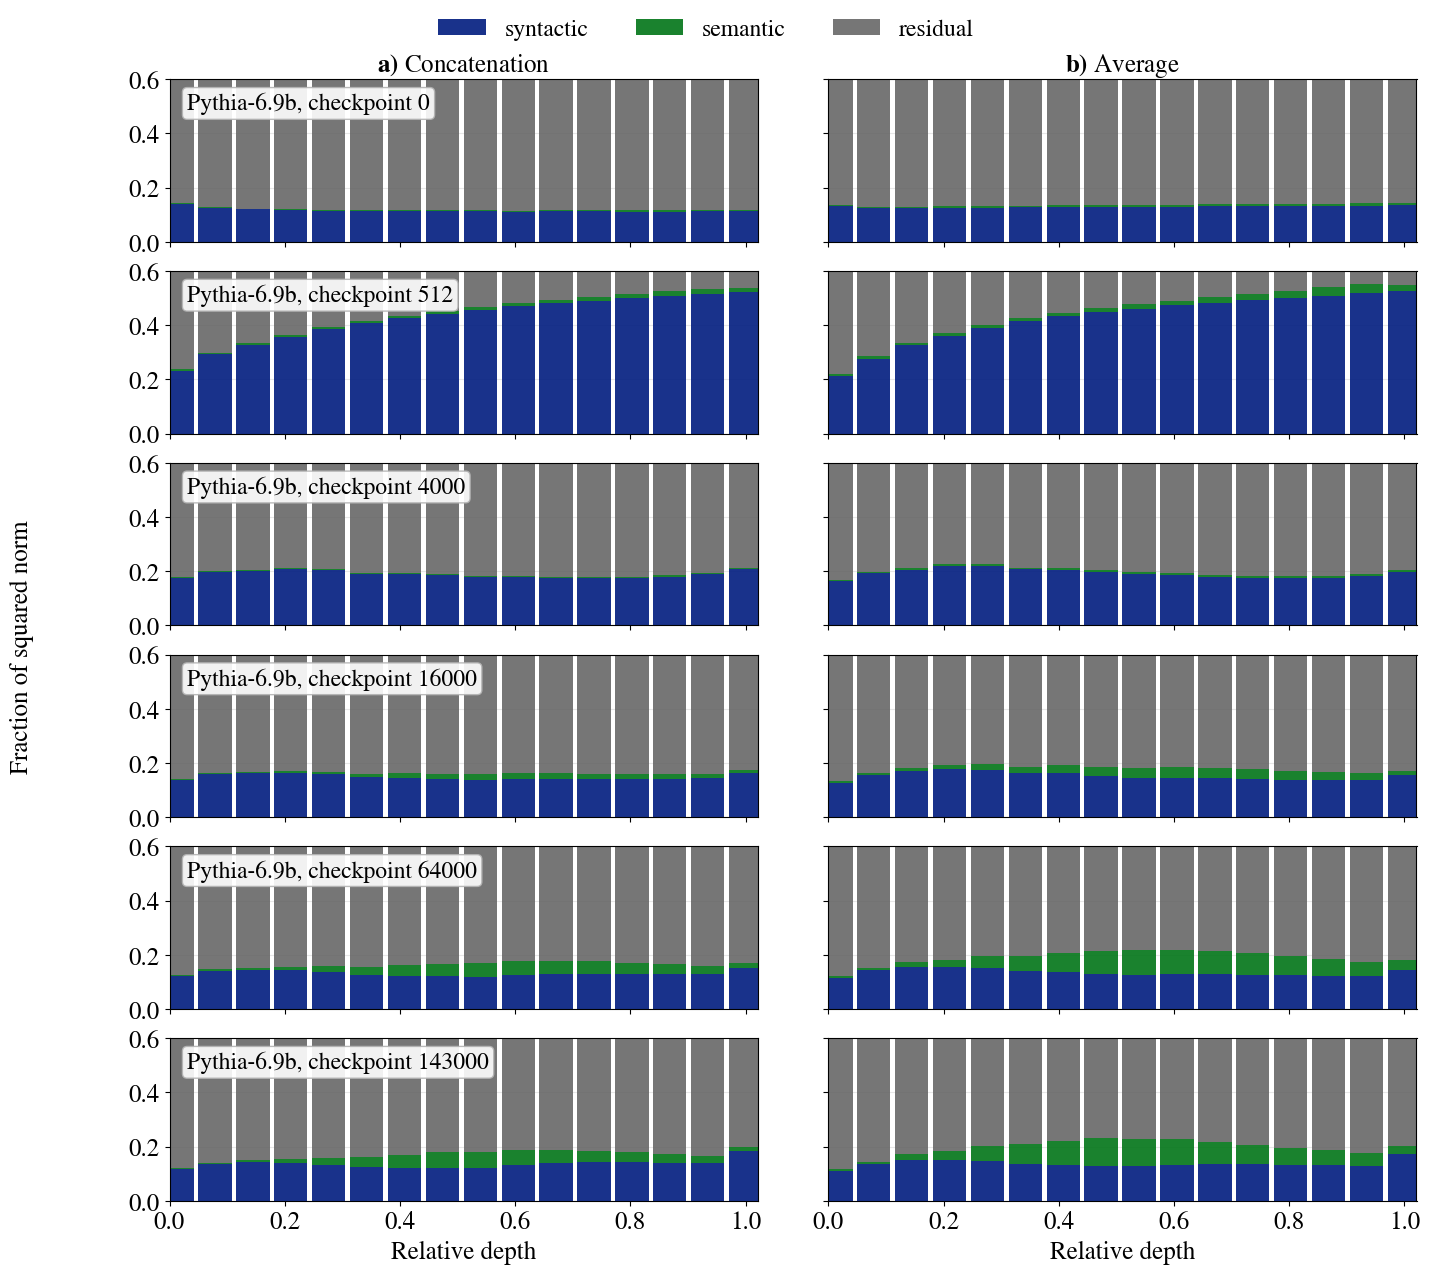

In [12]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

models = [
    'pythia6p9b_step0',
    'pythia6p9b_step512',
    'pythia6p9b_step4000',
    'pythia6p9b_step16000',
    'pythia6p9b_step64000',
    'pythia6p9b_step143000',
]
min_token_length = 3
n_samples = 2018
global_center_flag = 1

panel_specs = [
    ('Concat', 0, None),
    ('Avg', 1, None),
]

def load_run(base, avg_tokens, n_tokens=None):
    root = base / f'avg_tokens_{avg_tokens}' / f'min_token_length_{min_token_length}' / f'n_samples_{n_samples}'
    if avg_tokens == 0 and n_tokens not in (None, min_token_length):
        root = root / f'n_tokens_{n_tokens}'
    root = root / 'norms' / f'global_center_flag_{global_center_flag}'
    path = root / 'norms.npz'
    meta_path = root / 'metadata.json'
    if not path.exists():
        return None
    metadata = {}
    if meta_path.exists():
        metadata = json.loads(meta_path.read_text())
    return path, np.load(path), metadata

def normalized_component_stats(data):
    total = data['total_abs_dists']
    stats = {}
    for key in ('syn', 'sem', 'residual'):
        normalized = data[f'{key}_abs_dists'] / np.clip(total, 1e-8, None)
        stats[key] = {
            'means': normalized.mean(axis=1),
            'stds': normalized.std(axis=1),
        }
    return stats

def absolute_component_stats(data):
    stats = {}
    for key in ('syn', 'sem', 'residual'):
        stats[key] = {
            'means': data[f'{key}_abs_means'],
            'stds': data[f'{key}_abs_stds'],
        }
    return stats

layer_selection_mode = 'max'
# layer_selection_mode = 'central'

def selected_layer_index(values, data, mode=layer_selection_mode):
    if mode == 'central':
        return len(data['layer_vals']) // 2
    if mode == 'max':
        return int(np.argmax(values))
    raise ValueError(f'Unknown layer_selection_mode: {mode}')

def selection_label(mode=layer_selection_mode):
    if mode == 'central':
        return 'central-layer'
    if mode == 'max':
        return 'max'
    raise ValueError(f'Unknown layer_selection_mode: {mode}')

rcpsize = 18
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': False})

colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
syn_color = colors[0]
sem_color = colors[1]
residual_color = '#676767'
band_alpha = 0.18

bar_width = 0.055
panel_labels = {
    'Concat': r'$\mathbf{a)}$ Concatenation',
    'Avg': r'$\mathbf{b)}$ Average',
}

fig, axes = plt.subplots(len(models), len(panel_specs), figsize=(14.5, 2.1 * len(models)), sharex=True, sharey=True, squeeze=False)

for row, model in enumerate(models):
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {label: load_run(base, avg_tokens, n_tokens=n_tokens) for label, avg_tokens, n_tokens in panel_specs}

    for col, (label, avg_tokens, n_tokens) in enumerate(panel_specs):
        ax = axes[row, col]
        run = runs[label]
        if run is None:
            ax.text(0.5, 0.5, f'{label} missing', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        _, data, _ = run
        rel_depths = data['rel_depths']
        syn_means = data['syn_means']
        sem_means = data['sem_means']
        residual_means = data['residual_means']

        x = np.linspace(1 / len(rel_depths), 1, len(rel_depths))
        ax.bar(x, syn_means, width=bar_width, color=syn_color, label='syntactic', alpha=0.9)
        ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color=sem_color, label='semantic', alpha=0.9)
        ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, color=residual_color, label='residual', alpha=0.9)
        ax.set_xlim(0.05, 1.02)
        ax.set_ylim(0.0, 0.6)
        ax.set_xticks(np.linspace(0.05, 1.0, 6))
        ax.set_xticklabels([f'{tick:.1f}' for tick in np.linspace(0.0, 1.0, 6)])
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)
        if row == 0:
            ax.set_title(panel_labels[label], fontsize=rcpsize)
        if row == len(models) - 1:
            ax.set_xlabel('Relative depth', fontsize=rcpsize)
        if col == 0:
            checkpoint = model.split('step')[-1]
            ax.text(0.03, 0.92, f'Pythia-6.9b, checkpoint {checkpoint}', ha='left', va='top', transform=ax.transAxes, fontsize=rcpsize - 1, bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9, boxstyle='round,pad=0.2'))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.015), ncol=3, frameon=False, fontsize=rcpsize - 1)
fig.text(0.02, 0.5, 'Fraction of squared norm', va='center', rotation='vertical', fontsize=rcpsize)
plt.subplots_adjust(hspace=0.18, wspace=0.12, left=0.13, right=0.99, top=0.95, bottom=0.06)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_layerwise_norms_n2018.pdf', bbox_inches='tight')
plt.show()


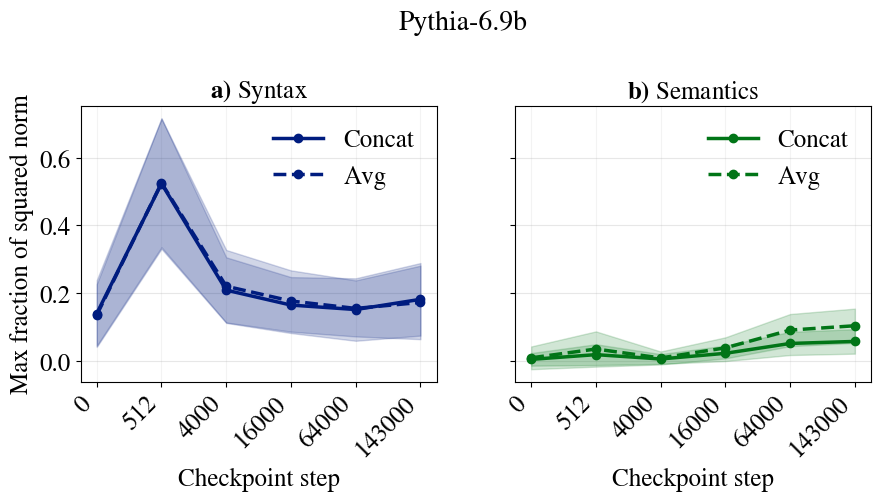

In [2]:
series_configs = [
    ('Concat', 0, None),
    ('Avg', 1, None),
]

checkpoint_steps = []
evolution = {label: {'syn': {'mean': [], 'std': []}, 'sem': {'mean': [], 'std': []}} for label, _, _ in series_configs}

for model in models:
    step = int(model.split('step')[-1])
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {label: load_run(base, avg_tokens, n_tokens=n_tokens) for label, avg_tokens, n_tokens in series_configs}
    if any(run is None for run in runs.values()):
        print(f'skipping {model}: missing norms output')
        continue

    checkpoint_steps.append(step)
    for label, _, _ in series_configs:
        _, data, _ = runs[label]
        stats = normalized_component_stats(data)
        for key in ('syn', 'sem'):
            idx = selected_layer_index(stats[key]['means'], data)
            evolution[label][key]['mean'].append(float(stats[key]['means'][idx]))
            evolution[label][key]['std'].append(float(stats[key]['stds'][idx]))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6), sharex=True, sharey=True)
plot_x = np.arange(len(checkpoint_steps))
linestyles = {'Concat': '-', 'Avg': '--'}
panel_meta = [('syn', syn_color, r'$\mathbf{a)}$ Syntax'), ('sem', sem_color, r'$\mathbf{b)}$ Semantics')]

for ax, (key, color, title) in zip(axes, panel_meta):
    for label, _, _ in series_configs:
        means = np.array(evolution[label][key]['mean'])
        stds = np.array(evolution[label][key]['std'])
        ax.plot(
            plot_x,
            means,
            marker='o',
            linewidth=2.5,
            linestyle=linestyles[label],
            color=color,
            label=label,
        )
        ax.fill_between(plot_x, means - stds, means + stds, color=color, alpha=band_alpha)
    ax.set_title(title, fontsize=rcpsize)
    ax.set_xticks(plot_x)
    ax.set_xticklabels([str(step) for step in checkpoint_steps], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xlabel('Checkpoint step', fontsize=rcpsize)
    ax.legend(loc='upper right', frameon=False)

axes[0].set_ylabel(f"{selection_label().capitalize()} fraction of squared norm", fontsize=rcpsize)
fig.suptitle('Pythia-6.9b', fontsize=rcpsize + 2, y=1.03)
plt.subplots_adjust(wspace=0.22, top=0.82, bottom=0.22)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'pythia6p9b_norms_checkpoint_evolution_n2018.pdf', bbox_inches='tight')
plt.show()


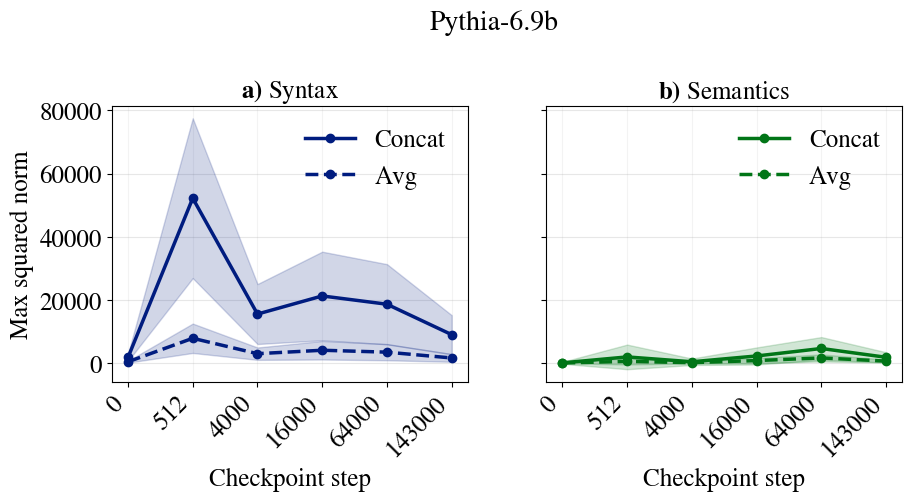

In [3]:
checkpoint_steps_abs = []
evolution_abs = {label: {'syn': {'mean': [], 'std': []}, 'sem': {'mean': [], 'std': []}} for label, _, _ in series_configs}

for model in models:
    step = int(model.split('step')[-1])
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    runs = {label: load_run(base, avg_tokens, n_tokens=n_tokens) for label, avg_tokens, n_tokens in series_configs}
    if any(run is None for run in runs.values()):
        print(f'skipping {model}: missing norms output')
        continue

    checkpoint_steps_abs.append(step)
    for label, _, _ in series_configs:
        _, data, _ = runs[label]
        stats = absolute_component_stats(data)
        for key in ('syn', 'sem'):
            idx = selected_layer_index(stats[key]['means'], data)
            evolution_abs[label][key]['mean'].append(float(stats[key]['means'][idx]))
            evolution_abs[label][key]['std'].append(float(stats[key]['stds'][idx]))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6), sharex=True, sharey=True)
plot_x = np.arange(len(checkpoint_steps_abs))

for ax, (key, color, title) in zip(axes, panel_meta):
    for label, _, _ in series_configs:
        means = np.array(evolution_abs[label][key]['mean'])
        stds = np.array(evolution_abs[label][key]['std'])
        ax.plot(
            plot_x,
            means,
            marker='o',
            linewidth=2.5,
            linestyle=linestyles[label],
            color=color,
            label=label,
        )
        ax.fill_between(plot_x, means - stds, means + stds, color=color, alpha=band_alpha)
    ax.set_title(title, fontsize=rcpsize)
    ax.set_xticks(plot_x)
    ax.set_xticklabels([str(step) for step in checkpoint_steps_abs], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xlabel('Checkpoint step', fontsize=rcpsize)
    ax.legend(loc='upper right', frameon=False)

axes[0].set_ylabel(f"{selection_label().capitalize()} squared norm", fontsize=rcpsize)
fig.suptitle('Pythia-6.9b', fontsize=rcpsize + 2, y=1.03)
plt.subplots_adjust(wspace=0.22, top=0.82, bottom=0.22)

plt.show()


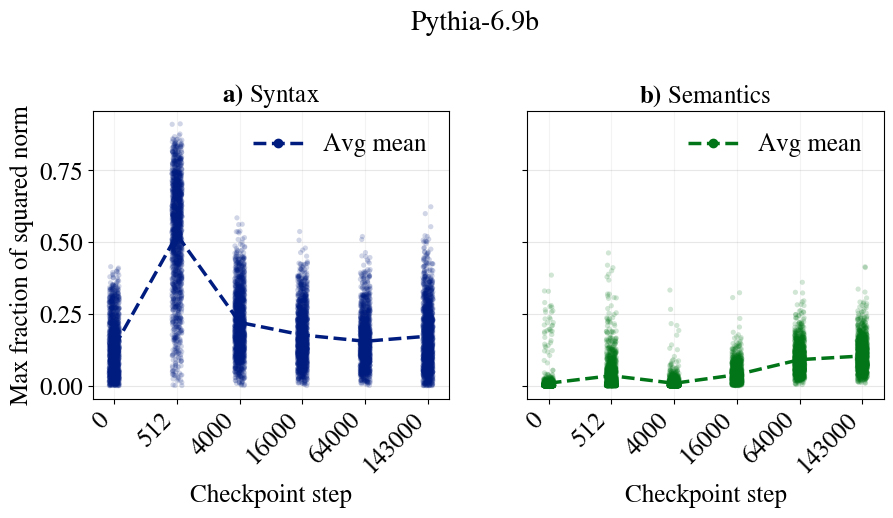

In [4]:
avg_config = ('Avg', 1, None)
avg_label, avg_tokens, avg_n_tokens = avg_config
checkpoint_steps_scatter = []
scatter_data = {'syn': [], 'sem': [], 'syn_mean': [], 'sem_mean': []}

for model in models:
    step = int(model.split('step')[-1])
    base = Path(f'/home/acevedo/syn-sem/pythia/results/model_{model}')
    run = load_run(base, avg_tokens, n_tokens=avg_n_tokens)
    if run is None:
        print(f'skipping {model}: missing avg norms output')
        continue

    _, data, _ = run
    stats = normalized_component_stats(data)
    syn_idx = selected_layer_index(stats['syn']['means'], data)
    sem_idx = selected_layer_index(stats['sem']['means'], data)

    checkpoint_steps_scatter.append(step)
    scatter_data['syn'].append(data['syn_abs_dists'][syn_idx] / np.clip(data['total_abs_dists'][syn_idx], 1e-8, None))
    scatter_data['sem'].append(data['sem_abs_dists'][sem_idx] / np.clip(data['total_abs_dists'][sem_idx], 1e-8, None))
    scatter_data['syn_mean'].append(float(stats['syn']['means'][syn_idx]))
    scatter_data['sem_mean'].append(float(stats['sem']['means'][sem_idx]))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.8), sharex=True, sharey=True)
plot_x = np.arange(len(checkpoint_steps_scatter))
jitter_width = 0.08
point_alpha = 0.18
point_size = 14

for ax, key, color, title in [
    (axes[0], 'syn', syn_color, r'$\mathbf{a)}$ Syntax'),
    (axes[1], 'sem', sem_color, r'$\mathbf{b)}$ Semantics'),
]:
    for idx, values in enumerate(scatter_data[key]):
        jitter = np.linspace(-jitter_width, jitter_width, len(values)) if len(values) > 1 else np.array([0.0])
        ax.scatter(np.full(len(values), plot_x[idx]) + jitter, values, s=point_size, alpha=point_alpha, color=color, edgecolors='none')
    ax.plot(plot_x, scatter_data[f'{key}_mean'], marker='o', linewidth=2.5, linestyle='--', color=color, label='Avg mean')
    ax.set_title(title, fontsize=rcpsize)
    ax.set_xticks(plot_x)
    ax.set_xticklabels([str(step) for step in checkpoint_steps_scatter], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xlabel('Checkpoint step', fontsize=rcpsize)
    ax.legend(loc='upper right', frameon=False)

axes[0].set_ylabel(f"{selection_label().capitalize()} fraction of squared norm", fontsize=rcpsize)
fig.suptitle('Pythia-6.9b', fontsize=rcpsize + 2, y=1.03)
plt.subplots_adjust(wspace=0.22, top=0.82, bottom=0.22)
plt.show()
